In [16]:
%matplotlib qt
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin

- 下面是你的函数调用部分

In [2]:
#function
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=1e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD_kuaisanjiao(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):
        G_DD_r[i][i] = g_ii[i]

    for i in range(N-1):
        G_DD_r[i][i+1] = g_ii[i] @ c_R[i+1]


    for i in range(N-1):
        G_DD_r[i+1][i] = g_ii[i+1] @ c_L[i]

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 
    
def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current
def Gr_DD_MS_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn+ 1j*1e-6)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])


    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod


    G_DD_wn = np.block(G_DD_r)
    A_DD_wn = np.block(A_DD)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS_gaiyixia(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    f_E= 1/(1+np.exp((1j*wn - mu)/KBT))
    G_DD_wn_xiao=f_E*(G_DD_wn.conj()-G_DD_wn)
    return G_DD_wn_xiao , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q1_q - G_q_q1 @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS_gaiyixia(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)


- 你的参数

In [11]:
#参数1
dela = 0.1875
t = 38*dela
af =1
a = 1
mu = 8*dela


hc=1.2#100
h =hc * np.sqrt(mu**2 + dela**2)
hz=0.93*dela
chaodaojiao = 0
#saimanjiao=np.pi/6
saimanjiao = np.pi*0


U = 1.9*dela
mz = 0.098614#0.098614 #【0.422270(mc=0,af=0，最小0)】,【0.098614(mc=1,af=1,最大1)】
mc=1
m =  h*mc
zhongjian_saimanjiao=np.pi*0
af6666=1

T_Tc=0.5
Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=10
q=3
shumu=int(np.floor(5 / T_Tc))
KBT=2 * dela * T_Tc / 3.5

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy +hz*sz
Delta_L=Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -1*t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])


H_center_block=(U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])


H_center_right_to_left_hop_block=-1*(t*s0+1j*af*sz*af6666/a)
H_center_right_to_left_hop=np.block([
        [ H_center_right_to_left_hop_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_right_to_left_hop_block.conj() ]
    ])


H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy +hz*sz
Delta_R=Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L
T_RD= H_R_to_center



In [20]:
#参数2
dela = 0.1875
t = 38*dela
af =1
a = 1
mu = 8*dela


hc=1.2#100
h =hc * np.sqrt(mu**2 + dela**2)
hz=0*dela
chaodaojiao = 0
#saimanjiao=np.pi/6
saimanjiao = np.pi*0


U = 1.9*dela

mz = 0#0.098614 #【0.422270(mc=0,af=0，最小0)】,【0.098614(mc=1,af=1,最大1)】
mz=0.04
mc=1
m =  h*mc
zhongjian_saimanjiao=np.pi*0
af6666=1

T_Tc=0.5
Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=10
q=3
shumu=int(np.floor(5 / T_Tc))
KBT=2 * dela * T_Tc / 3.5

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy +hz*sz
Delta_L=Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -1*t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])


H_center_block=(U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])


H_center_right_to_left_hop_block=-1*(t*s0+1j*af*sz*af6666/a)
H_center_right_to_left_hop=np.block([
        [ H_center_right_to_left_hop_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_right_to_left_hop_block.conj() ]
    ])


H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy +hz*sz
Delta_R=Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L
T_RD= H_R_to_center



- 你在用一个包扫-np.imag(yigeshu)/np.pi的峰值

In [13]:
# ABS扫点
phi_set = np.linspace(0, 2*np.pi, 21)     # 超导相位
sdsd=3
E_min, E_max = -Delta *sdsd, Delta *sdsd

phi_list = []
E_peak_list = []

for phi in phi_set:
    chaodaojiao = phi

    Delta_L = Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_L_onsite = np.block([
        [ HL_block,          Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
    H_R_onsite = np.block([
        [ HR_block,          Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])


    H_l = H_L_onsite
    H_r = H_R_onsite

    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)


    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=20, xtol=1e-5, ftol=1e-5)


    for E_peak in peak_energies:
        phi_list.append(phi)
        E_peak_list.append(E_peak)


plt.figure(figsize=(6,4))
plt.scatter(phi_list, E_peak_list, s=6)
plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E$/ $\Delta$")
plt.title(
    f'ABS\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.xlim(0, 2*np.pi)
#plt.ylim(E_min, E_max)
plt.ylim(E_min, E_max)
plt.yticks(
    [E_min,  E_min/2, 0,  E_max/2, E_max],
    [-1*sdsd, -1*sdsd/2, 0, 1*sdsd/2, 1*sdsd]
)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.show()


- np.imag(yigeshu)/np.pi

In [18]:
# ABS视图
num_ef = 101
efmin = -Delta*3
efmax = Delta*3
def_ = (efmax - efmin) / num_ef
num_phi = 101
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        Delta_L = Delta * np.exp(-1j * phi / 2) * 1j * sy
        H_L_onsite = np.block([
            [HL_block, Delta_L],
            [Delta_L.conj().T, -HL_block.conj()]
        ])
        Delta_R = Delta * np.exp(+1j * phi / 2) * 1j * sy
        H_R_onsite = np.block([
            [HR_block, Delta_R],
            [Delta_R.conj().T, -HR_block.conj()]
        ])
        H_l = H_L_onsite
        H_r = H_R_onsite
        
        # Compute G_DD_r
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_DD_r)

# ... 前面的循环计算 ef_plot, phi_plot, ABS 保持不变 ...

# Figure
fig, ax = plt.subplots(figsize=(8, 7))
def on_motion(event):
    if event.inaxes == ax and event.xdata is not None and event.ydata is not None:
        msg = f'x = {event.xdata:.3f}   y = {event.ydata:.3f}'
        fig.canvas.toolbar.set_message(msg)
    else:
        fig.canvas.toolbar.set_message('')

fig.canvas.mpl_connect('motion_notify_event', on_motion)

X, Y = np.meshgrid(phi_plot, ef_plot)

# 1. 画底图（pcolormesh）
im = ax.pcolormesh(
    X, Y,
    np.log(ABS + 1e-10),
    shading='auto',
    cmap='viridis',          # 或 'hot', 'magma', 'inferno' 等，根据喜好
    rasterized=True
)
cbar = plt.colorbar(im, ax=ax, location='right', label=r'$\log(|\mathrm{bufeng}(G_{DD})| + \epsilon)$')

# 2. 在网格点上叠加 scatter（用于 hover）
#    可以选择每隔几点画一个，避免太密集（例如 step=2 或 3）
step = 1   # 调大一点可以减少点数，提高性能；设为1就是全部点
scatters = []

xx = X[::step, ::step].ravel()   # 展平
yy = Y[::step, ::step].ravel()
zz = np.log(ABS + 1e-10)[::step, ::step].ravel()

sc = ax.scatter(
    xx, yy,
    c=zz,                   # 颜色跟底图保持一致
    s=18,                   # 点的大小，建议 12~25
    cmap='viridis',
    alpha=0.0,              # ! 关键：设为 0 或 0.01，让点“隐形”，只用来 hover
    edgecolor='none',
    rasterized=True
)
scatters.append(sc)

# 如果你希望点稍微可见，也可以设 alpha=0.15 ~ 0.3，并加 edgecolor

# 3. 添加交互（hover 显示信息）
import mplcursors

cursor = mplcursors.cursor(scatters, hover=True)

@cursor.connect("add")
def on_add(sel):
    # sel.index 是展平后的索引
    i_flat = sel.index
    # 还原到二维索引（大约）
    row = (i_flat // (X.shape[1]//step)) * step
    col = (i_flat % (X.shape[1]//step)) * step
    
    phi_val = phi_plot[col]
    ef_val  = ef_plot[row]
    abs_log = np.log(ABS[row, col] + 1e-10)
    abs_raw = ABS[row, col]
    
    sel.annotation.set_text(
        f"φ/π = {phi_val:.3f}\n"
        f"E/Δ  = {ef_val/Delta:.3f}\n"
        f"log(ABS) ≈ {abs_log:.4f}\n"
        f"bufeng ≈ {abs_raw:.2e}"
    )
    sel.annotation.get_bbox_patch().set_alpha(0.85)  # 背景稍透明

# 美化
ax.set_xlabel(r'$\phi / \pi$')
ax.set_ylabel(r'$E / \Delta$')
ax.set_yticks([efmin/Delta, efmin/Delta, 0, efmax/Delta, efmax/Delta])
ax.set_yticklabels([efmin/Delta, efmin/Delta, 0, efmax/Delta, efmax/Delta])
ax.set_title(
    f'ABS spectrum\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ',
    fontsize=10
)

ax.axis('tight')
ax.set_aspect('auto')   

plt.show()

- J vs /phi

In [19]:
#J vs /phi
phi_list = np.linspace(0, 2*np.pi, 101)
J_list = []

for phi in phi_list:
    chaodaojiao = phi

    Delta_L = Delta * np.exp(-1j*phi/2) * 1j * sy
    H_l = np.block([
        [ HL_block,         Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = Delta * np.exp(+1j*phi/2) * 1j * sy
    H_r = np.block([
        [ HR_block,         Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    Jphi = J_matsubara_sum(
        shumu=shumu,
        H_q=H_q,
        H_l=H_l,
        H_r=H_r,
        T_12=T_12,
        T_LD=T_LD,
        T_l=T_l,
        T_RD=T_RD,
        T_r=T_r,
        N=N,
        q=q
    )

    J_list.append(Jphi)

plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'Josephson current $J$')
plt.title(
    f'J vs $\\varphi$\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.show()



- 这个是来判定是不是正常流的

In [9]:
def J_of_phi(phi):

    Delta_L = Delta * np.exp(-1j*phi/2) * 1j * sy
    H_l = np.block([
        [ HL_block,         Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = Delta * np.exp(+1j*phi/2) * 1j * sy
    H_r = np.block([
        [ HR_block,         Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    Jphi = J_matsubara_sum(
        shumu=shumu,
        H_q=H_q,
        H_l=H_l,
        H_r=H_r,
        T_12=T_12,
        T_LD=T_LD,
        T_l=T_l,
        T_RD=T_RD,
        T_r=T_r,
        N=N,
        q=q
    )

    return Jphi
def find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-6, ftol=1e-6,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)

    yinzi = (abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, J_min, yinzi
J_of_phi(0),J_of_phi(np.pi),J_of_phi(2*np.pi)

(-0.00611638656109706, -0.0447165252699497, -0.00611638656109736)

- 这个是在扫一个j vs /phi的yinzi

In [10]:
def find_J_extreme_fmin_ceshi(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-6, ftol=1e-6,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    # 找真正极值
    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi = (abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, (phi_at_Jmax)/np.pi-2, J_min, phi_at_Jmin/np.pi, abs(yinzi)
find_J_extreme_fmin_ceshi(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)

(-0.0027538041446062652,
 0.18098963026625947,
 -0.04658898872501732,
 1.1308595326451532,
 0.8883806941417959)

- 你在扫一个yinzi,这里用了两次扫最小值，所以有点慢就是了

In [18]:
def abs_yinzi_of_mz(mz_val):
    global mz, H_q

    if mz_val < 0 or mz_val > 3*Delta:
        raise ValueError("mz out of range")

    # 如果mz_val是数组（从fmin传入），转为标量
    if isinstance(mz_val, np.ndarray):
        mz_val = mz_val.item()  # 或 mz_val[0] 如果是(1,)数组

    mz = mz_val

    H_center_block = (U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy

    H_q = np.block([
        [ H_center_block, np.zeros((2,2)) ],
        [ np.zeros((2,2)), -H_center_block.conj() ]
    ])

    J_max, phi_max, J_min, phi_min, yinzi = find_J_extreme_fmin_ceshi(
        phi_min=0,
        phi_max=2*np.pi,
        N_guess=4,
        xtol=1e-3,
        ftol=1e-3
    )

    # 确保yinzi是标量
    if isinstance(yinzi, np.ndarray):
        yinzi = yinzi.item()  # 转为float

    val = abs(yinzi)

    # print时直接转为float
    print(f"mz = {mz_val:.6f}  |yinzi| = {float(val):.6f}")

    return val
def find_yinzi_extreme_mz(mz_min=0*Delta, mz_max=2*Delta,
                         N_guess=3, xtol=1e-6, ftol=1e-6,
                         round_digits=6):

    mz_guesses = np.linspace(mz_min, mz_max, N_guess)

    max_list = []
    min_list = []

    global_best_max = -np.inf
    global_best_max_mz = None

    global_best_min = np.inf
    global_best_min_mz = None

    for mz0 in mz_guesses:

        print("\n===== Starting guess mz =", mz0, "=====")

        # ---------- 找最大 ----------
        try:

            rmax = fmin(lambda mz: -abs_yinzi_of_mz(mz),
                        mz0,
                        disp=False,
                        xtol=xtol,
                        ftol=ftol)

            max_list.append(rmax[0])

        except ValueError:

            print("Stop search (mz out of range)")

        # ---------- 找最小 ----------
        try:

            rmin = fmin(lambda mz: abs_yinzi_of_mz(mz),
                        mz0,
                        disp=False,
                        xtol=xtol,
                        ftol=ftol)

            min_list.append(rmin[0])

        except ValueError:

            print("Stop search (mz out of range)")


    mz_max_list = np.unique(np.round(max_list, round_digits))
    mz_min_list = np.unique(np.round(min_list, round_digits))

    # ----------- 计算真正最大 ----------
    for mz_val in mz_max_list:

        val = abs_yinzi_of_mz(mz_val)

        if val > global_best_max:

            global_best_max = val
            global_best_max_mz = mz_val

            print("\n>>> NEW GLOBAL MAX")
            print("mz =", mz_val)
            print("|yinzi| =", val)


    # ----------- 计算真正最小 ----------
    for mz_val in mz_min_list:

        val = abs_yinzi_of_mz(mz_val)

        if val < global_best_min:

            global_best_min = val
            global_best_min_mz = mz_val

            print("\n>>> NEW GLOBAL MIN")
            print("mz =", mz_val)
            print("|yinzi| =", val)


    return global_best_max, global_best_max_mz, global_best_min, global_best_min_mz
yinzi_max, mz_max, yinzi_min, mz_min = find_yinzi_extreme_mz()

print("\n====== FINAL RESULT ======")
print("max |yinzi| =", yinzi_max, " at mz =", mz_max)
print("min |yinzi| =", yinzi_min, " at mz =", mz_min)


===== Starting guess mz = 0.0 =====
mz = 0.000000  |yinzi| = 0.124695
mz = 0.000250  |yinzi| = 0.121591
Stop search (mz out of range)
mz = 0.000000  |yinzi| = 0.124695
mz = 0.000250  |yinzi| = 0.121591
mz = 0.000500  |yinzi| = 0.118486
mz = 0.000750  |yinzi| = 0.115381
mz = 0.001250  |yinzi| = 0.109172
mz = 0.001750  |yinzi| = 0.102962
mz = 0.002750  |yinzi| = 0.090541
mz = 0.003750  |yinzi| = 0.078119
mz = 0.005750  |yinzi| = 0.053271
mz = 0.007750  |yinzi| = 0.028418
mz = 0.011750  |yinzi| = 0.021302
mz = 0.015750  |yinzi| = 0.071040
mz = 0.015750  |yinzi| = 0.071040
mz = 0.009750  |yinzi| = 0.003561
mz = 0.007750  |yinzi| = 0.028418
mz = 0.010750  |yinzi| = 0.008870


KeyboardInterrupt: 

- 这三只是一个因子画图

In [ ]:
mz_list = np.linspace(0*Delta, 2*Delta, 11)
yinzi_list = np.zeros(len(mz_list))

for i, mz_val in enumerate(mz_list):
    hz= 0
    mz = mz_val

    HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy +hz*sz
    Delta_R=Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
    H_r= H_R_onsite

    HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy +hz*sz
    Delta_L=Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
    H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
    H_l= H_L_onsite

    H_center_block=(U-mu+2*t)*s0+mz*sz
    H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    H_q = H_center
    J_max, J_min, yinzi = find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)

    yinzi_list[i] = yinzi

    print(f"mz = {mz_val:.3f}, yinzi = {yinzi:.6f}")



plt.figure()

plt.plot(mz_list/dela, yinzi_list, 'o-', linewidth=2)

plt.xlabel(r'$m_z$/$\Delta$')
plt.ylabel(r'$\eta$')

plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

mz = 0.000, yinzi = -0.000000
mz = 0.059, yinzi = 0.000149
mz = 0.118, yinzi = 0.000331
mz = 0.176, yinzi = 0.000589
mz = 0.235, yinzi = 0.000968
mz = 0.294, yinzi = 0.001462
mz = 0.353, yinzi = 0.001686
mz = 0.411, yinzi = 0.000432
mz = 0.470, yinzi = -0.001843
mz = 0.529, yinzi = -0.002786
mz = 0.588, yinzi = -0.002767
mz = 0.646, yinzi = -0.002481
mz = 0.705, yinzi = -0.001915
mz = 0.764, yinzi = -0.000690
mz = 0.823, yinzi = 0.000808
mz = 0.881, yinzi = 0.001187
mz = 0.940, yinzi = 0.001362
mz = 0.999, yinzi = 0.001600
mz = 1.058, yinzi = 0.001773
mz = 1.117, yinzi = 0.001871
mz = 1.175, yinzi = 0.001917
mz = 1.234, yinzi = 0.001933
mz = 1.293, yinzi = 0.001935
mz = 1.352, yinzi = 0.001932
mz = 1.410, yinzi = 0.001930
mz = 1.469, yinzi = 0.001934
mz = 1.528, yinzi = 0.001945
mz = 1.587, yinzi = 0.001964
mz = 1.645, yinzi = 0.001990
mz = 1.704, yinzi = 0.002024
mz = 1.763, yinzi = 0.002065


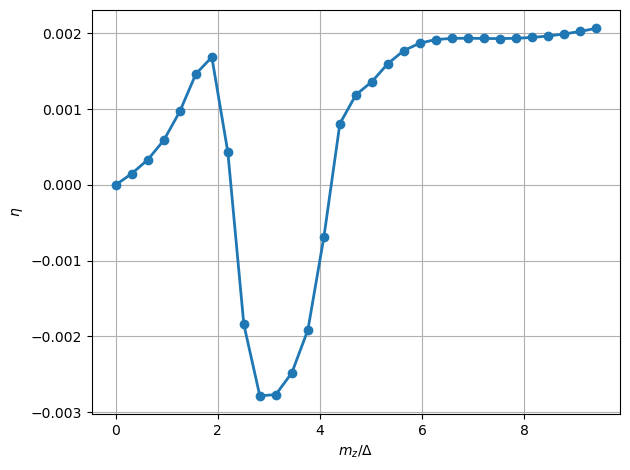

In [ ]:
mz_list = np.linspace(0*Delta, 10*Delta, 31)
yinzi_list = np.zeros(len(mz_list))

for i, mz_val in enumerate(mz_list):
    hz= 0
    mz = mz_val

    HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy +hz*sz
    Delta_R=Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
    H_r= H_R_onsite

    HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy +hz*sz
    Delta_L=Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
    H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
    H_l= H_L_onsite

    H_center_block=(U-mu+2*t)*s0+mz*sz
    H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    H_q = H_center
    
    J_max, J_min, yinzi = find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)

    yinzi_list[i] = yinzi

    print(f"mz = {mz_val:.3f}, yinzi = {yinzi:.6f}")



plt.figure()

plt.plot(mz_list/dela, yinzi_list, 'o-', linewidth=2)

plt.xlabel(r'$m_z$/$\Delta$')
plt.ylabel(r'$\eta$')

plt.grid(True)
plt.tight_layout()
plt.show()

0 0 1.3734015774577261e-14
0 1 7.443849703815536e-15
0 2 -8.249242813575058e-14
0 3 1.548290595234669e-14
0 4 -3.7189971540983204e-14
0 5 2.6077182418975608e-14
0 6 6.65114745697634e-15
0 7 -3.756213070436806e-14
0 8 1.4851716221259774e-14
0 9 2.1043646763530668e-14
0 10 -2.6494542854537203e-14
1 0 -0.5973394775626029
1 1 -0.22381671806450443
1 2 -0.24708933456055415
1 3 -0.6627654556510216
1 4 -0.4635306941620387
1 5 -0.35794134805354766
1 6 -0.28944924958358076
1 7 -0.2414589180406441
1 8 -0.206361763253581
1 9 -0.17939024324970404
1 10 -0.15764834515983855
2 0 -0.8322820960721388
2 1 -0.4488178392274839
2 2 -0.49633005157050686
2 3 -0.7561503576268019
2 4 -0.9264749217422463
2 5 -0.7156064859829679
2 6 -0.5787263297478829
2 7 -0.4828055468615169
2 8 -0.4126482745150148
2 9 -0.35872689921968015
2 10 -0.31525581806185743
3 0 -0.5504018442305852
3 1 -0.6761655283385445
3 2 -0.7500422627273502
3 3 -0.5059825336249014
3 4 -0.7203286381866938
3 5 -0.9322096248463652
3 6 -0.867659349944580

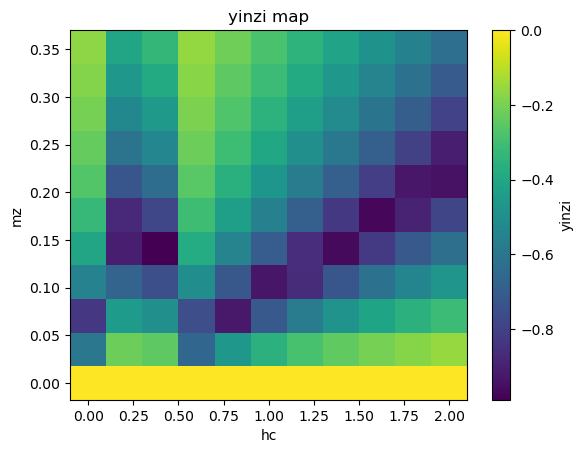

In [ ]:
num_mz = 11
num_hc = 11

mz_list = np.linspace(0, 2*Delta, num_mz)
hc_list = np.linspace(0, 2, num_hc)

yinzi_map = np.zeros((num_mz, num_hc))
for i_mz, mz_val in enumerate(mz_list):

    for j_hc, hc_val in enumerate(hc_list):

        mz = mz_val
        mc = hc_val
        m =  h*mc

        h = hc * np.sqrt(mu**2 + dela**2)

        H_center_block = (U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy
        H_q = np.block([
            [ H_center_block, np.zeros((2,2)) ],
            [ np.zeros((2,2)), -H_center_block.conj() ]
        ])


        J_max, J_min, yinzi = find_J_extreme_fmin()

        yinzi_map[i_mz, j_hc] = yinzi

        print(i_mz, j_hc, yinzi)
plt.figure()

X, Y = np.meshgrid(hc_list, mz_list)

plt.pcolormesh(X, Y, yinzi_map, shading='auto')

plt.colorbar(label='yinzi')

plt.xlabel('hc')
plt.ylabel('mz')

plt.title('yinzi map')

plt.axis('tight')
plt.show()